In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


<h3>Selection of features</h3> 
<p>Since the task is to find clusters for archtiypical charging sessions and not for how requests from registered users deviate from the actual charging session, we decided to only incorporate features that are not in the user inputs. Moreover, we calculated two measures from connectionTime, disconnectTime and doneChargingTime. The charging_duration is the timespan between connectionTime and doneChargingTime and the idle_time is the timespan from doneChargingTime to disconnectTime. With this calculation we decreased dimensionality from 4 to only 3 explainable features.</p>

In [121]:
# Calculate timespans
full_charging_df['charging_duration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['idle_time'] = (full_charging_df['disconnectTime'] - full_charging_df['doneChargingTime']).dt.total_seconds() / 60

In [122]:
# Select features for clustering
features = [
    'idle_time',
    'charging_duration',
    'kWhDelivered',
]

In [123]:
# Drop rows with NaN values
X = full_charging_df[features].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)
print(X.head())

(65037, 3)
(60923, 3)
    idle_time  charging_duration  kWhDelivered
0   99.666667         262.683333        25.016
1  140.266667         401.250000        33.097
2  484.266667         158.516667         6.521
3   79.900000          78.783333         2.355
4  231.166667         257.483333        13.375


In [124]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,idle_time,charging_duration,kWhDelivered
0,-0.297589,0.278395,1.322543
1,-0.128455,1.032134,2.118411
2,1.304600,-0.288225,-0.498962
3,-0.379934,-0.721938,-0.909256
4,0.250221,0.250109,0.176064


In [125]:
from sklearn.cluster import KMeans

In [126]:
k_max = 15 # TODO: Are 15 enough?
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

(0.0, 14.0)

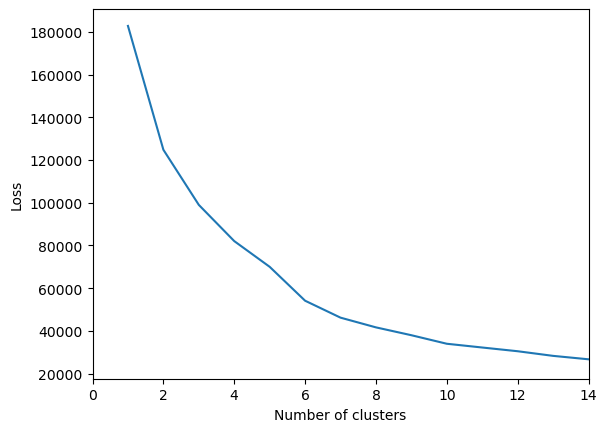

In [127]:
# Plot the loss curve to find the optimal number of clusters
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,14])

/Applications/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


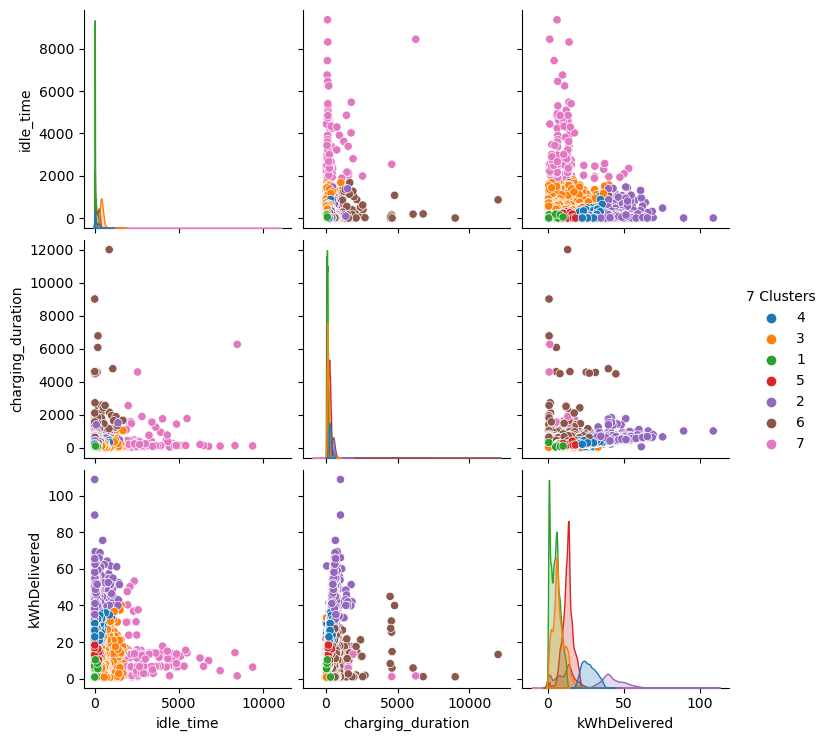

In [128]:
numbers = ["1", "2", "3", "4", "5", "6", "7"]

# refit algorithm
seven_means = KMeans(n_clusters=7, n_init='auto')
seven_means.fit(clustering_scaled_df)

X["7 Clusters"] = seven_means.predict(clustering_scaled)
X["7 Clusters"] = X["7 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="7 Clusters")

/Applications/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


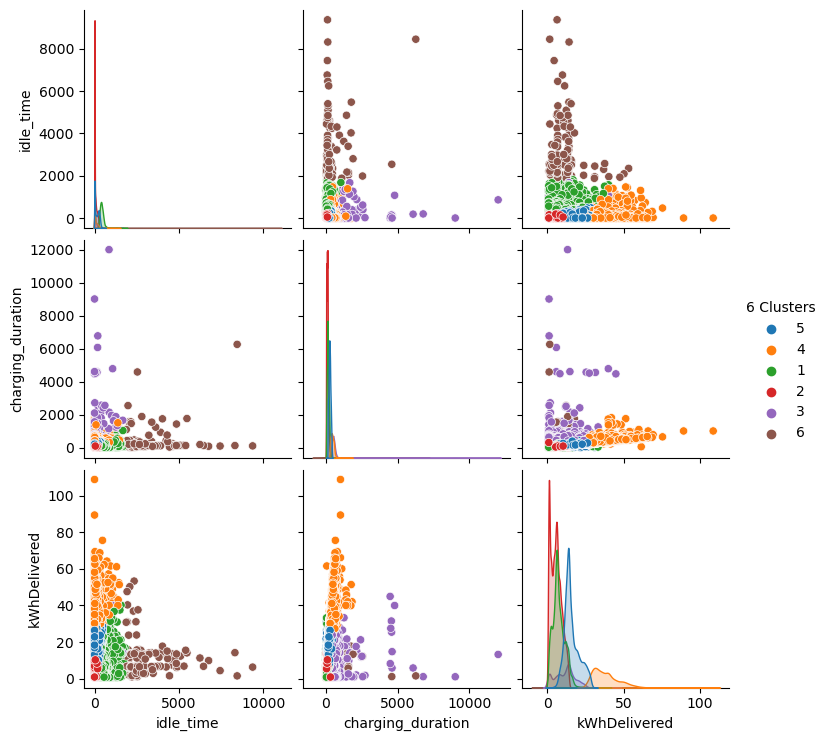

In [129]:
six_means = KMeans(n_clusters=6, n_init='auto')
# refit algorithm without column for 7 clusters
six_means.fit(clustering_scaled_df)
X["6 Clusters"] = six_means.predict(clustering_scaled)
X["6 Clusters"] = X["6 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="6 Clusters")

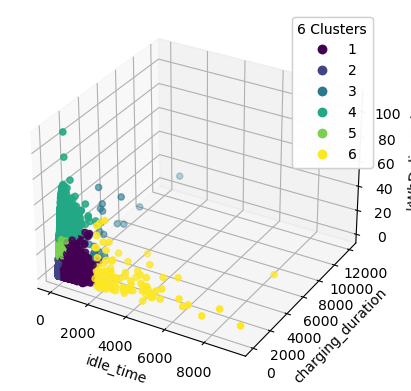

In [130]:
from mpl_toolkits.mplot3d import Axes3D

# 3D-Scatter-Plot erstellen
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Konvertiere Cluster-Labels in numerische Werte
cluster_labels = X["6 Clusters"].astype(int)

# Datenpunkte plotten
scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=cluster_labels, cmap='viridis')

# Achsenbeschriftungen
ax.set_xlabel(X.columns[0])
ax.set_ylabel(X.columns[1])
ax.set_zlabel(X.columns[2])

# Legende hinzufügen
legend1 = ax.legend(*scatter.legend_elements(), title="6 Clusters")
ax.add_artist(legend1)

# Plot anzeigen
plt.show()

In [131]:
# Berechne min, max und median für jede Funktion in jedem Cluster
X_six_clusters = X.drop(columns="7 Clusters")
cluster_stats = X_six_clusters.groupby("6 Clusters").agg(['min', 'max', 'median'])

# Ausgabe der Ergebnisse
print(cluster_stats)

           idle_time                           charging_duration  \
                 min          max       median               min   
6 Clusters                                                         
1             216.00  1890.350000   403.016667          0.000000   
2               0.00   275.933333     8.533333          0.050000   
3               0.00  1669.700000    19.516667        351.000000   
4               0.00  1467.516667    42.066667         69.283333   
5               0.00   622.983333   120.141667         21.983333   
6            1875.85  9367.283333  2798.483333         31.000000   

                                     kWhDelivered                       
                     max      median          min         max   median  
6 Clusters                                                              
1            1048.750000  133.316667        0.502   40.111000   6.5280  
2             356.283333   92.333333        0.501   14.547000   5.2780  
3           12000.9500

<h4>Cluster Description</h4>
<p><b>Cluster 1: Also parking </b>-> Charging Events with a medium high idle_time and generally lower charging_duration and kWh_delivered</p>
<p><b>Cluster 2: Short Charges </b>-> Charging Events with the lowest idle_time, charging_duration and kWh_delivered</p>
<p><b>Cluster 3: Long Charges </b>-> Charging Events with the highest charging_duration but medium high kWh_delivered</p>
<p><b>Cluster 4: Heavy kWh Charges </b>-> Charging Events with the highest kWh_delivered and long charging_time</p>
<p><b>Cluster 5: Medium Charges </b>-> Charging Events with medium idle_time, charging_duration and kWh_delivered</p>
<p><b>Cluster 6: Mainly Parking </b>-> Charging Events with the highest idle_time and mixed charging_duration and kWh_delivered</p>

